<a href="https://colab.research.google.com/github/AlexeyTri/SemMed_fall25/blob/main/Seminar2/SemMed2_fall25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Создание нейронных сетей с помощью PyTorch

## Тензоры PyTorch

Основная структура данных PyTorch — тензор . 2 Это многомерный массив с формой и типом данных, используемый для численных вычислений. У тензора есть две дополнительные особенности: он может работать на GPU (или других аппаратных ускорителях, как мы увидим) и поддерживает автоматическое дифференцирование. Каждая нейронная сеть, которую мы построим с этого момента, будет принимать и выводить тензоры (подобно тому, как модели Scikit-Learn принимают и выводят массивы NumPy). Итак, начнём с того, как создавать и обрабатывать тензоры.

In [1]:
import torch
import numpy as np

In [2]:
X = torch.tensor([[1.0, 4.0, 7.0], [2.0, 3.0, 6.0]])
X

tensor([[1., 4., 7.],
        [2., 3., 6.]])

Как и массив NumPy, тензор может содержать числа с плавающей точкой, целые числа, логические значения или комплексные числа — только один тип данных для каждого тензора. При инициализации тензора значениями разных типов будет выбран наиболее общий тип (например, complex > float > integer > bool). Вы также можете явно выбрать тип данных при создании тензора, например, dtype=torch.float16для 16-битных чисел с плавающей точкой. Обратите внимание, что тензоры строк и объектов не поддерживаются.

In [3]:
X.shape, X.dtype

(torch.Size([2, 3]), torch.float32)

In [4]:
10 * (X + 1.0)

tensor([[20., 50., 80.],
        [30., 40., 70.]])

In [5]:
X.exp()

tensor([[   2.7183,   54.5981, 1096.6332],
        [   7.3891,   20.0855,  403.4288]])

In [6]:
X.mean()

tensor(3.8333)

In [7]:
X.max(dim=0)

torch.return_types.max(
values=tensor([2., 4., 7.]),
indices=tensor([1, 0, 0]))

In [8]:
X @ X.T

tensor([[66., 56.],
        [56., 49.]])

In [9]:
torch.FloatTensor(np.array([[1., 4., 7.], [2., 3., 6]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]])

PyTorch предоставляет множество операций in-place, таких как abs_(), sqrt_(), и zero_(), которые напрямую изменяют входной тензор: иногда они могут сэкономить память и ускорить ваши модели. Например, relu_()метод применяет функцию активации ReLU in-place, заменяя все отрицательные значения нулями:

In [10]:
X.relu_()
X

tensor([[1., 4., 7.],
        [2., 3., 6.]])

## Аппаратное ускорение

Тензоры PyTorch можно легко скопировать на графический процессор (GPU), если на вашем компьютере установлен совместимый графический процессор и все необходимые библиотеки. В Colab достаточно убедиться, что вы используете среду выполнения GPU: для этого перейдите в меню «Среда выполнения» и выберите «Изменить тип среды выполнения», а затем убедитесь, что выбран графический процессор (например, графический процессор Nvidia T4). В среде выполнения GPU автоматически будет установлена ​​соответствующая библиотека PyTorch, скомпилированная с поддержкой GPU, а также соответствующие драйверы GPU и все остальные необходимые библиотеки (например, библиотеки CUDA и cuDNN от Nvidia).

In [11]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [12]:
device

'cuda'

In [13]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]])

In [14]:
M = M.to(device)

In [15]:
M.device

device(type='cuda', index=0)

In [16]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]], device=device)

Если у вас несколько графических процессоров Nvidia, вы можете обратиться к нужному графическому процессору, добавив индекс графического процессора: "cuda:0"(или просто "cuda") для графического процессора №0, "cuda:1"для графического процессора №1 и т. д.

In [17]:
R = M @ M.T
R

tensor([[14., 32.],
        [32., 77.]], device='cuda:0')

In [18]:
M = torch.rand((1000, 1000))  # on the CPU
%timeit M @ M.T

25.6 ms ± 727 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [19]:
M = torch.rand((1000, 1000), device="cuda")  # on the GPU
%timeit M @ M.T

528 µs ± 10.9 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## Autograd -автоматический градиент.



In [20]:
x = torch.tensor(5.0, requires_grad=True)
y = torch.tensor(7.0, requires_grad=True)
f = x ** 2 + y ** 2
f

tensor(74., grad_fn=<AddBackward0>)

In [21]:
f.backward() # формирует обратный граф вычисления производной соответсвующей
x.grad, y.grad

(tensor(10.), tensor(14.))

In [22]:
learning_rate = 0.1
with torch.no_grad():
    x -= learning_rate * x.grad  # gradient descent step

In [23]:
x

tensor(4., requires_grad=True)

Другой способ избежать вычисления градиента — использовать метод переменной detach(): это создаёт новый тензор, отсоединённый от графа вычислений, с requires_grad=False, но по-прежнему указывающий на те же данные в памяти. Затем вы можете обновить этот отсоединённый тензор:

In [24]:
x_detached = x.detach()
x_detached -= learning_rate * x.grad

Поскольку x_detachedи xиспользуют одну и ту же память, изменение x_detachedтакже изменяет x.

Прежде чем повторять весь процесс (прямой проход + обратный проход + шаг градиентного спуска), необходимо обнулить градиенты каждого параметра модели ( no_grad()для этого вам не нужен контекст, поскольку тензор градиента имеет requires_grad=False):

In [25]:
x.grad.zero_()

tensor(0.)

Если собрать все воедино, то весь цикл обучения выглядит так:

In [26]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
    f = x ** 2  # forward pass 1 step: f = 25 /2 step: f = 4 ** 2 = 16 ... f -> 0
    f.backward()  # backward pass 2 * x
    with torch.no_grad():
        x -= learning_rate * x.grad  # gradient descent step 5 - 0.1 * 2 * 5 = 5 - 1 = 4/ 2 step: x = 4 - 0.1 * 2 * 4 = 3.2/ x = 0.000000001

    x.grad.zero_()  # reset the gradients

## Реализация линейной регрессии

In [27]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [28]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

In [29]:
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_valid = torch.FloatTensor(y_valid).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

In [30]:
torch.manual_seed(42)
n_features = X_train.shape[1]  # there are 8 input features
w = torch.randn((n_features, 1), requires_grad=True)
b = torch.tensor(0., requires_grad=True)

In [31]:
x = torch.FloatTensor([1, 2, 3, 4, 5, 6])
x

tensor([1., 2., 3., 4., 5., 6.])

In [32]:
x.reshape(1, -1), x.reshape(-1, 1)

(tensor([[1., 2., 3., 4., 5., 6.]]),
 tensor([[1.],
         [2.],
         [3.],
         [4.],
         [5.],
         [6.]]))

In [33]:
torch.manual_seed(42)

# y - target
# y^ = X @ w + b
# X.shape[0] - l, X.shape[1] - features
# w.shape = [features, 1] для одного элемента, W[n_features, l]
# b.shape = 1 для одного элемента, b[l, 1]
# y, y^.shape[l, 1]
# loss = y - y^: loss -> 0 GD

n_features = X_train.shape[1]  # there are 8 input features
w = torch.randn((n_features, 1), requires_grad=True) # w.shaep = 8 * 1. X.shape[0] - row, X.shape[1] - columns
b = torch.tensor(0., requires_grad=True) # b.shape = 1

Теперь у нас есть параметр весов w(вектор-столбец с одним весом на каждое входное измерение, в данном случае 8) и параметр смещения b(один скаляр). Веса инициализируются случайным образом, а смещение — нулевым. В этом случае мы могли бы инициализировать веса нулевым значением, но когда мы перейдём к нейронным сетям, важно будет инициализировать веса случайным образом, чтобы нарушить симметрию между нейронами , так что давайте выработаем эту привычку уже сейчас.

In [34]:
learning_rate = 0.4
n_epochs = 20
for epoch in range(n_epochs):
    y_pred = X_train @ w + b
    loss = ((y_pred - y_train) ** 2).mean() # в примере ранее мы рассматривали функцию x^2
    loss.backward()
    with torch.no_grad():
        b -= learning_rate * b.grad
        w -= learning_rate * w.grad
        b.grad.zero_()
        w.grad.zero_()
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

Epoch 1/20, Loss: 16.158456802368164
Epoch 2/20, Loss: 4.8793745040893555
Epoch 3/20, Loss: 2.255225419998169
Epoch 4/20, Loss: 1.3307636976242065
Epoch 5/20, Loss: 0.9680693745613098
Epoch 6/20, Loss: 0.8142675757408142
Epoch 7/20, Loss: 0.7417045831680298
Epoch 8/20, Loss: 0.7020700573921204
Epoch 9/20, Loss: 0.6765917539596558
Epoch 10/20, Loss: 0.6577963829040527
Epoch 11/20, Loss: 0.6426151394844055
Epoch 12/20, Loss: 0.6297222971916199
Epoch 13/20, Loss: 0.6184941530227661
Epoch 14/20, Loss: 0.6085968017578125
Epoch 15/20, Loss: 0.5998216271400452
Epoch 16/20, Loss: 0.592018723487854
Epoch 17/20, Loss: 0.5850691795349121
Epoch 18/20, Loss: 0.578873336315155
Epoch 19/20, Loss: 0.573345422744751
Epoch 20/20, Loss: 0.5684100389480591


Давайте рассмотрим этот код:

* Сначала мы определяем learning_rate гиперпараметр. Вы можете экспериментировать с различными значениями, чтобы найти значение, которое быстро сходится и даёт точный результат.

* Далее мы запускаем 20 эпох. Мы могли бы реализовать раннюю остановку, чтобы найти подходящий момент для остановки и избежать переобучения. (ДЗ)

* Далее мы выполняем прямой проход: вычисляем прогнозы y_predи среднеквадратичную ошибку loss.

* Затем мы loss.backward()вычисляем градиенты потерь по каждому параметру модели. Это и есть autograd в действии.

* Затем мы используем градиенты b.grad и w.grad для выполнения шага градиентного спуска. Обратите внимание, что мы запускаем этот код внутри with torch.no_grad() контекста, как обсуждалось ранее.

* После того как мы выполнили шаг градиентного спуска, мы сбрасываем градиенты на ноль (очень важно!).

* Наконец, мы выводим номер эпохи и текущие потери в каждой эпохе. item() Метод извлекает значение скаляра.

In [35]:
X_new = X_test[:3]
with torch.no_grad():
    y_pred = X_new @ w + b
y_pred

tensor([[0.8916],
        [1.6480],
        [2.6577]])

In [36]:
y_test[:3]

tensor([[0.4770],
        [0.4580],
        [5.0000]])

In [37]:
import torch.nn as nn  # by convention, this module is usually imported this way

torch.manual_seed(42)  # to get reproducible results
model = nn.Linear(in_features=n_features, out_features=1)

In [38]:
model.bias, model.weight

(Parameter containing:
 tensor([0.3117], requires_grad=True),
 Parameter containing:
 tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
        requires_grad=True))

In [39]:
model(X_train[:2]), y_train[:2]

(tensor([[-0.4718],
         [ 0.1131]], grad_fn=<AddmmBackward0>),
 tensor([[1.4420],
         [1.6870]]))

Теперь, когда у нас есть модель, нам нужно создать оптимизатор для обновления параметров модели, а также выбрать функцию потерь:

In [40]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

PyTorch предоставляет несколько различных оптимизаторов (мы обсудим их в следующей главе). Здесь мы используем простой оптимизатор стохастического градиентного спуска (SGD), который можно использовать для SGD, мини-пакетного GD или пакетного градиентного спуска. Для его инициализации необходимо задать параметры модели и скорость обучения.

Для функции потерь мы создаём экземпляр класса nn.MSELoss: это также модуль, поэтому мы можем использовать его как функцию, передавая ему прогнозы и цели, и он вычислит среднеквадратичную ошибку (MSE). Модуль nnсодержит множество других функций потерь и других инструментов нейронной сети, как мы увидим далее. Далее напишем небольшую функцию для обучения нашей модели:

In [41]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
    for epoch in range(n_epochs):
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

Вот несколько моментов, на которые стоит обратить внимание:

* В PyTorch объект функции потерь обычно называют критерием , чтобы отличать его от самого значения потерь (которое вычисляется на каждой итерации обучения с использованием критерия). В данном примере это MSELossэкземпляр.

* Строка optimizer.step()соответствует двум обновленным строкам bи wв нашем предыдущем коде.

* И, конечно же, эта optimizer.zero_grad()строка соответствует двум строкам, обнулённым функциями b.gradи w.grad. Обратите внимание, что здесь нам не нужно использовать , with torch.no_grad()так как это автоматически делает оптимизатор внутри функций step()и zero_grad().

In [42]:
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 4.3378496170043945
Epoch 2/20, Loss: 0.7802939414978027
Epoch 3/20, Loss: 0.6253842115402222
Epoch 4/20, Loss: 0.6060433983802795
Epoch 5/20, Loss: 0.5956299304962158
Epoch 6/20, Loss: 0.587356686592102
Epoch 7/20, Loss: 0.5802990794181824
Epoch 8/20, Loss: 0.5741382241249084
Epoch 9/20, Loss: 0.5687101483345032
Epoch 10/20, Loss: 0.5639079809188843
Epoch 11/20, Loss: 0.5596511363983154
Epoch 12/20, Loss: 0.5558737516403198
Epoch 13/20, Loss: 0.5525194406509399
Epoch 14/20, Loss: 0.5495392084121704
Epoch 15/20, Loss: 0.5468900203704834
Epoch 16/20, Loss: 0.5445339679718018
Epoch 17/20, Loss: 0.5424376726150513
Epoch 18/20, Loss: 0.5405716300010681
Epoch 19/20, Loss: 0.5389097332954407
Epoch 20/20, Loss: 0.5374288558959961


In [43]:
X_new = X_test[:3]
with torch.no_grad():
    y_pred = X_new @ w + b
y_pred, y_test[:3]

(tensor([[0.8916],
         [1.6480],
         [2.6577]]),
 tensor([[0.4770],
         [0.4580],
         [5.0000]]))

PyTorch предоставляет полезный nn.Sequentialмодуль, объединяющий несколько модулей в цепочку: когда вы вызываете этот модуль с некоторыми входными данными, он передаёт эти входные данные первому модулю, затем передаёт выходные данные первого модуля второму и так далее. Большинство нейронных сетей содержат стеки модулей, и, по сути, многие нейронные сети представляют собой один большой стек модулей: это делает nn.Sequentialмодуль одним из самых полезных модулей в PyTorch. Многослойный перцептрон (MLP), который мы хотим построить, — это просто стек модулей — два скрытых слоя и один выходной слой. Давайте создадим его с помощью nn.Sequentialмодуля:

In [44]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), # w.shape[0]
    nn.ReLU(),
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1) # y^
)

Давайте рассмотрим каждый слой:

* Первый слой должен иметь необходимое количество входов для наших данных n_features(в нашем случае 8). Однако количество выходов может быть любым: давайте возьмём 50 (это гиперпараметр, который мы можем настроить).

* Далее идёт nn.ReLUмодуль, реализующий функцию активации ReLU для первого скрытого слоя. Этот модуль не содержит параметров модели и действует поэлементно, поэтому форма его выходных данных совпадает с формой входных данных.

* Второй скрытый слой должен иметь то же количество входов, что и выход предыдущего слоя: в данном случае 50. Однако у него может быть любое количество выходов. Обычно во всех скрытых слоях используется одинаковое количество измерений выходов, но в этом примере я использовал 40, чтобы подчеркнуть, что выход одного слоя должен соответствовать входу следующего слоя.

* Затем nn.ReLUмодуль для реализации функции активации второго скрытого слоя.

* Наконец, выходной слой должен иметь 40 входов, но на этот раз количество выходов не является произвольным: оно должно соответствовать размерности целевых элементов. Поскольку наши целевые элементы имеют одно измерение, в выходном слое должно быть только одно выходное измерение.

In [45]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 5.045480251312256
Epoch 2/20, Loss: 2.0523123741149902
Epoch 3/20, Loss: 1.0039883852005005
Epoch 4/20, Loss: 0.8570138216018677
Epoch 5/20, Loss: 0.7740675210952759
Epoch 6/20, Loss: 0.7225848436355591
Epoch 7/20, Loss: 0.6893726587295532
Epoch 8/20, Loss: 0.6669032573699951
Epoch 9/20, Loss: 0.650773823261261
Epoch 10/20, Loss: 0.6383934020996094
Epoch 11/20, Loss: 0.6281994581222534
Epoch 12/20, Loss: 0.6193399429321289
Epoch 13/20, Loss: 0.6113173365592957
Epoch 14/20, Loss: 0.6038705706596375
Epoch 15/20, Loss: 0.5968307852745056
Epoch 16/20, Loss: 0.5901118516921997
Epoch 17/20, Loss: 0.583646833896637
Epoch 18/20, Loss: 0.5774063467979431
Epoch 19/20, Loss: 0.5713554620742798
Epoch 20/20, Loss: 0.5654447674751282


### Реализация мини-пакетного градиентного спуска с использованием загрузчиков данных
Для реализации мини-пакетного (GD) PyTorch предоставляет класс, названный DataLoaderв torch.utils.dataмодуле. Он может эффективно загружать пакеты данных желаемого размера и перемешивать данные на каждой эпохе, если это необходимо. Предполагается, что DataLoaderнабор данных будет представлен как объект с как минимум двумя методами: __len__(self)для получения количества выборок в наборе данных и __getitem__(self, index)для загрузки выборки по заданному индексу (включая целевой).
В нашем случае обучающий набор доступен в тензорах X_trainи y_train, поэтому сначала нам нужно обернуть эти тензоры в объект набора данных . Для этого PyTorch предоставляет TensorDatasetкласс. Давайте создадим класс TensorDatasetдля обертывания нашего обучающего набора и класс DataLoaderдля извлечения пакетов из этого набора данных. Во время обучения мы хотим, чтобы набор данных перемешивался, поэтому указываем shuffle=True:

In [46]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Теперь, когда у нас есть более крупная модель и инструменты для её обучения по одному пакету за раз, самое время начать использовать аппаратное ускорение. Это довольно просто: нам нужно просто перенести модель на графический процессор, который перенесёт все её параметры в его оперативную память, а затем в начале каждой итерации обучения мы должны копировать каждый пакет на графический процессор. Для переноса модели мы можем просто использовать её to() метод, как мы делали с тензорами:

In [47]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 1)
)

model = model.to(device)

# extra code – build the optimizer and loss function, as earlier
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()

In [48]:
def train(model, optimizer, criterion, train_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        mean_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}")

In [49]:
train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss: 0.5900
Epoch 2/20, Loss: 0.4046
Epoch 3/20, Loss: 0.3801
Epoch 4/20, Loss: 0.3629
Epoch 5/20, Loss: 0.3529
Epoch 6/20, Loss: 0.3520
Epoch 7/20, Loss: 0.3408
Epoch 8/20, Loss: 0.3427
Epoch 9/20, Loss: 0.3406
Epoch 10/20, Loss: 0.3378
Epoch 11/20, Loss: 0.3304
Epoch 12/20, Loss: 0.3267
Epoch 13/20, Loss: 0.3244
Epoch 14/20, Loss: 0.3221
Epoch 15/20, Loss: 0.3186
Epoch 16/20, Loss: 0.3149
Epoch 17/20, Loss: 0.3123
Epoch 18/20, Loss: 0.3111
Epoch 19/20, Loss: 0.3088
Epoch 20/20, Loss: 0.3072


Всё сработало отлично: мы действительно достигли гораздо меньших потерь за то же количество эпох! Однако вы, вероятно, заметили, что каждая эпоха была гораздо медленнее. Есть два простых трюка, которые можно использовать, чтобы значительно ускорить обучение:

Если вы используете устройство CUDA, обычно следует задать это pin_memory=Trueпри создании загрузчика данных: это позволит разместить данные в памяти с блокировкой страниц, что гарантирует фиксированное расположение физической памяти в оперативной памяти процессора и, следовательно, позволит осуществлять передачу данных по технологии прямого доступа к памяти (DMA) в графический процессор, устраняя необходимость в дополнительной операции копирования. Хотя это может занять больше оперативной памяти процессора, поскольку память не может быть выгружена на диск, обычно это приводит к значительно более быстрой передаче данных и, следовательно, к более быстрому обучению. При передаче тензора в графический процессор с использованием этого to()метода можно также настроить non_blocking=True, чтобы избежать блокировки центрального процессора во время передачи данных (это работает только в том случае, если pin_memory=True).

Текущий цикл обучения ожидает полной обработки пакета, прежде чем загружать следующий. Часто можно ускорить обучение, предварительно выполнив загрузку следующих пакетов на центральном процессоре, пока графический процессор продолжает работать с текущим пакетом. Для этого установите num_workersаргумент загрузчика данных на количество процессов, которые вы хотите использовать для загрузки и предварительной обработки данных. Оптимальное количество зависит от вашей платформы, оборудования и рабочей нагрузки, поэтому следует поэкспериментировать с различными значениями. Вы также можете настроить количество пакетов, предварительно выгружаемых каждым обработчиком, установив аргумент загрузчика данных prefetch_factor. Обратите внимание, что накладные расходы на создание и синхронизацию обработчиков часто могут замедлить обучение, а не ускорить его (особенно в Windows). В этом случае можно попробовать настроить persistent_workers=Trueповторное использование одних и тех же обработчиков в разных эпохах.

## Оценка модели

Давайте напишем функцию для оценки модели. Она принимает модель и DataLoaderнабор данных, на котором мы хотим оценить модель, а также функцию для вычисления метрики для заданного пакета и, наконец, функцию для агрегирования метрик пакета (по умолчанию она просто вычисляет среднее значение):

In [50]:
def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [51]:
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)
valid_mse = evaluate(model, valid_loader, mse)
valid_mse

tensor(0.4080, device='cuda:0')

Всё работает отлично. Но теперь предположим, что мы хотим использовать среднеквадратичную ошибку (RMSE) вместо среднеквадратической ошибки (MSE) . В PyTorch нет встроенной функции для этого, но это достаточно просто написать:

In [52]:
def rmse(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean().sqrt()

evaluate(model, valid_loader, rmse)

tensor(0.5668, device='cuda:0')

Но подождите секунду! Среднеквадратическая ошибка (RMSE) должна быть равна квадратному корню из среднеквадратической ошибки (MSE); однако, когда мы вычисляем квадратный корень из найденной ранее MSE, мы получаем другой результат:

In [53]:
valid_mse.sqrt()

tensor(0.6388, device='cuda:0')

Причина в том, что вместо того, чтобы вычислять среднеквадратичную ошибку (СКО) для всего проверочного набора, мы вычисляли её для каждого пакета, а затем вычисляли среднеквадратичную ошибку (СКО) для всех этих пакетов. Математически это не эквивалентно вычислению СКО для всего проверочного набора. Чтобы решить эту проблему, мы можем использовать СКО в качестве metric_fn, а затем использовать aggregate_fnдля вычисления квадратного корня из среднего значения СКО:

In [54]:
evaluate(model, valid_loader, mse,
         aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))

tensor(0.6388, device='cuda:0')

In [55]:
!pip install torchmetrics
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 24.8 MB/s eta 0:00:00


In [56]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

Затем мы можем создать потоковую метрику RMSE, перенести ее в графический процессор и использовать ее для оценки проверочного набора:

In [57]:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model, valid_loader, rmse)

tensor(0.6388, device='cuda:0')

In [58]:
import matplotlib.pyplot as plt


Epoch 1/20, train loss: 0.7826, train metric: 0.8847, valid metric: 0.6690
Epoch 2/20, train loss: 0.4362, train metric: 0.6605, valid metric: 0.6099
Epoch 3/20, train loss: 0.3930, train metric: 0.6269, valid metric: 0.6145
Epoch 4/20, train loss: 0.3759, train metric: 0.6132, valid metric: 0.5963
Epoch 5/20, train loss: 0.3649, train metric: 0.6040, valid metric: 0.5911
Epoch 6/20, train loss: 0.3598, train metric: 0.5999, valid metric: 0.5965
Epoch 7/20, train loss: 0.3530, train metric: 0.5941, valid metric: 0.6061
Epoch 8/20, train loss: 0.3495, train metric: 0.5911, valid metric: 0.6043
Epoch 9/20, train loss: 0.3455, train metric: 0.5877, valid metric: 0.5723
Epoch 10/20, train loss: 0.3416, train metric: 0.5846, valid metric: 0.6043
Epoch 11/20, train loss: 0.3401, train metric: 0.5831, valid metric: 0.5882
Epoch 12/20, train loss: 0.3362, train metric: 0.5799, valid metric: 0.5738
Epoch 13/20, train loss: 0.3352, train metric: 0.5788, valid metric: 0.5873
Epoch 14/20, train lo

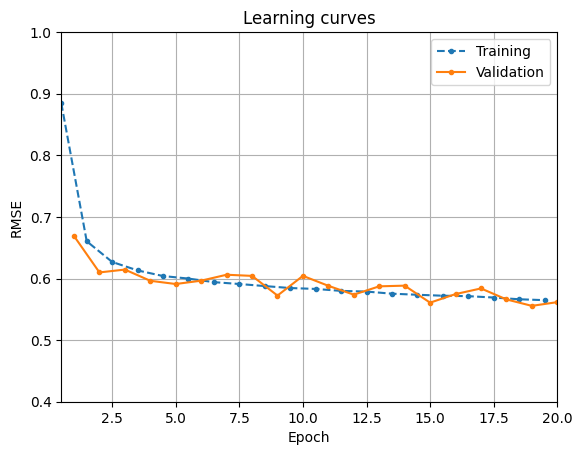

In [59]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                 n_epochs)

# Since we compute the training metric
plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
         label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",
         label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
plt.axis([0.5, 20, 0.4, 1.0])
plt.legend()
plt.show()

## Создание классификатора изображений с помощью PyTorch

Использование TorchVision для загрузки набора данных
Библиотека TorchVision — важная часть экосистемы PyTorch: она предоставляет множество инструментов для компьютерного зрения, включая служебные функции для загрузки распространённых наборов данных, таких как MNIST или Fashion MNIST, а также предобученные модели для различных задач компьютерного зрения ? функции преобразования изображений (например, обрезки, поворота, изменения размера и т. д.) и многое другое. Она предустановлена ​​в Colab, поэтому давайте воспользуемся ею для загрузки Fashion MNIST. Она уже разделена на обучающий набор (60 000 изображений) и тестовый набор (10 000 изображений), но мы сохраним последние 5000 изображений из обучающего набора для проверки, используя random_split()функцию PyTorch:

In [60]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.6MB/s]


После импорта и перед загрузкой наборов данных мы создаём toTensorобъект. Что это такое? По умолчанию FashionMNISTкласс загружает изображения как PIL (Python Image Library) с целочисленными значениями пикселей в диапазоне от 0 до 255. Но нам нужны тензоры с плавающей точкой PyTorch с масштабированными значениями пикселей. К счастью, наборы данных TorchVision принимают transformаргумент, позволяющий передать функцию предварительной обработки, которая будет выполняться «на лету» при каждом доступе к данным (есть также target_transformаргумент, если требуется предварительная обработка целевых данных). TorchVision предоставляет множество объектов преобразований, которые можно использовать для этого (большинство этих преобразований являются модулями PyTorch).

В этом коде мы создаём Composeпреобразование для цепочки двух преобразований: одно ToImageпреобразование, а затем другое ToDtypeпреобразование. ToImageпреобразует различные форматы, включая изображения PIL, массивы NumPy и тензоры, в Imageкласс TorchVision, который является подклассом Tensor. ToDtypeПреобразование преобразует тип данных, в данном случае в 32-битные числа с плавающей точкой. Мы также устанавливаем его scaleаргумент равным , Trueчтобы обеспечить масштабирование значений в диапазоне от 0,0 до 1,0.

Затем мы загружаем набор данных: сначала обучающие и проверочные данные, затем тестовые. rootАргумент — это путь к каталогу, в котором TorchVision создаст подкаталог для набора данных Fashion MNIST. trainАргумент указывает, хотите ли вы загрузить обучающий набор ( Trueпо умолчанию) или тестовый набор. downloadАргумент указывает, следует ли загружать набор данных, если он не найден локально ( Falseпо умолчанию). Мы также настраиваем transform=toTensorиспользование нашего собственного конвейера предварительной обработки.

In [61]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [62]:
X_sample, y_sample = train_data[0]

Каждый тензор изображения имеет 3 измерения, и его форма выглядит следующим образом: [1, 28, 28]. Первое измерение — это измерение канала . Для изображений в оттенках серого существует один канал (цветные изображения обычно имеют три канала). Два других измерения — это измерения высоты и ширины. Например, X_sample[0, 2, 4]представляет пиксель, расположенный в канале 0, строке 2, столбце 4. В Fashion MNIST большее значение соответствует более темному пикселю.

Что касается целевых значений, то они представляют собой целые числа от 0 до 9, и мы можем интерпретировать их, используя тот же class_namesмассив. На самом деле, многие наборы данных, включая FashionMNIST, имеют classes атрибут, содержащий список имён классов. Например, вот как можно определить, что на изображении образца изображен ботильоны:

In [63]:
train_and_valid_data.classes[y_sample]

'Ankle boot'

Создание классификатора

In [64]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1), # 1*28*28 =1*784
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes) # n_classes = 10
        )

    def forward(self, X):
        return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

В этом коде есть несколько моментов, на которые следует обратить внимание:

* Во-первых, модель состоит из одной последовательности слоёв, поэтому мы использовали nn.Sequentialмодуль. Нам не пришлось создавать собственный модуль; мы могли бы написать его model = nn.Sequential(...)самостоятельно, но, как правило, предпочтительнее заключать модели в собственные модули, поскольку это упрощает развёртывание и повторное использование кода, а также упрощает настройку гиперпараметров.

* Модель начинается со nn.Flattenслоя: этот слой не имеет параметров, он просто преобразует каждый входной образец в одно измерение, необходимое для nn.Linearслоёв. Например, пакет из 32 изображений Fashion MNIST имеет форму [32, 1, 28, 28], но после прохождения через nn.Flattenслой он принимает форму [32, 784](поскольку 28 × 28 = 784).

* Первый скрытый слой должен иметь правильное количество входов (28 × 28 = 784), а выходной слой должен иметь правильное количество выходов (10, по одному на класс).

* Мы используем функцию активации ReLU после каждого скрытого слоя и не используем функцию активации вообще после выходного слоя.

* Поскольку это задача многоклассовой классификации, мы используем nn.CrossEntropyLoss. В качестве целей она принимает либо индексы классов (как в этом примере), либо вероятности классов (например, одноклассовые векторы).

In [65]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
_ = train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader,
           n_epochs)

Epoch 1/20, train loss: 0.6058, train metric: 0.7816, valid metric: 0.8416
Epoch 2/20, train loss: 0.4059, train metric: 0.8497, valid metric: 0.8372
Epoch 3/20, train loss: 0.3633, train metric: 0.8663, valid metric: 0.8530
Epoch 4/20, train loss: 0.3359, train metric: 0.8762, valid metric: 0.8660
Epoch 5/20, train loss: 0.3147, train metric: 0.8835, valid metric: 0.8754
Epoch 6/20, train loss: 0.2991, train metric: 0.8881, valid metric: 0.8666
Epoch 7/20, train loss: 0.2859, train metric: 0.8916, valid metric: 0.8622
Epoch 8/20, train loss: 0.2745, train metric: 0.8971, valid metric: 0.8722
Epoch 9/20, train loss: 0.2639, train metric: 0.9007, valid metric: 0.8834
Epoch 10/20, train loss: 0.2531, train metric: 0.9041, valid metric: 0.8810
Epoch 11/20, train loss: 0.2463, train metric: 0.9068, valid metric: 0.8850
Epoch 12/20, train loss: 0.2353, train metric: 0.9109, valid metric: 0.8910
Epoch 13/20, train loss: 0.2303, train metric: 0.9125, valid metric: 0.8870
Epoch 14/20, train lo

In [67]:
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

Теперь, когда модель обучена, мы можем использовать её для прогнозирования новых изображений. В качестве примера давайте сделаем прогнозы для первой партии в проверочном наборе и посмотрим на результаты для первых трёх изображений:

In [68]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)  # index of the largest logit
y_pred

tensor([7, 4, 2], device='cuda:0')

In [69]:
[train_and_valid_data.classes[index] for index in y_pred]

['Sneaker', 'Coat', 'Pullover']

In [70]:
import torch.nn.functional as F
y_proba = F.softmax(y_pred_logits, dim=1)
if device == "mps":
    y_proba = y_proba.cpu()
y_proba.cpu().round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0000, 0.9110, 0.0000,
         0.0880],
        [0.0000, 0.0000, 0.0040, 0.0000, 0.9960, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.6250, 0.0000, 0.3350, 0.0000, 0.0390, 0.0000, 0.0000,
         0.0000]])

Часто бывает полезно получить k лучших предсказаний модели . Для этого можно использовать torch.topk()функцию, которая возвращает кортеж, содержащий как k лучших значений, так и их индексы:

In [73]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1)
if device == "mps":
    y_top4_probas = y_top4_probas.cpu()
y_top4_probas.round(decimals=3), y_top4_indices


(tensor([[0.9110, 0.0880, 0.0010, 0.0000],
         [0.9960, 0.0040, 0.0000, 0.0000],
         [0.6250, 0.3350, 0.0390, 0.0000]], device='cuda:0'),
 tensor([[7, 9, 5, 8],
         [4, 2, 6, 0],
         [2, 4, 6, 0]], device='cuda:0'))

Для первого изображения лучшим предположением модели является класс 7 (кроссовки) с уверенностью 95,7%, вторым лучшим предположением является класс 9 (ботинки) с уверенностью 8% и т. д.

!!! Набор данных Fashion MNIST сбалансирован, то есть содержит одинаковое количество экземпляров каждого класса. При работе с несбалансированным набором данных обычно следует придавать больший вес редким классам и меньший — часто встречающимся, иначе ваша модель будет смещена в сторону более частых классов. Это можно сделать, установив weightаргумент nn.CrossEntropyLoss. Например, если есть три класса с 900, 700 и 400 экземплярами соответственно (т.е. всего 2000 экземпляров), то соответствующие веса должны быть 2000/900, 2000/700 и 2000/400. Предпочтительно нормализовать эти веса, чтобы их сумма равнялась 1, поэтому в этом примере следует установить weight=torch.tensor([0.2205, 0.2835, 0.4961]).

## Тонкая настройка гиперпараметров нейронной сети с помощью Optuna

Рассмотрим пример использования Optuna. Он не предустановлен в Colab, поэтому нам нужно установить его с помощью %pip install optuna(если вы предпочитаете запускать код локально, следуйте инструкциям по установке по адресу https://homl.info/install-p ). Давайте настроим скорость обучения и количество нейронов в скрытых слоях (для простоты мы будем использовать одинаковое количество нейронов в обоих скрытых слоях). Сначала нам нужно определить функцию, которую Optuna будет вызывать многократно для настройки гиперпараметров: эта функция должна принимать Trialобъект и использовать его для запроса у Optuna значений гиперпараметров, а затем использовать эти значения для построения и обучения модели. Наконец, функция должна оценить модель (обычно на проверочном наборе) и вернуть метрику:

In [74]:
!pip install optuna
import optuna

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs=10)
    validation_accuracy = max(history["valid_metrics"])
    return validation_accuracy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 10.7 MB/s eta 0:00:00


Методы suggest_float()и suggest_int()позволяют нам запросить у Optuna подходящее значение гиперпараметра в заданном диапазоне (Optuna также предоставляет соответствующий suggest_categorical()метод). Для learning_rateгиперпараметра мы запрашиваем значение от 10–5 до 10–1 , и, поскольку мы не знаем оптимального масштаба, добавляем log=True: . Это заставит Optuna выбирать значения из логарифмического распределения, что позволит ей исследовать все возможные масштабы. Если бы мы использовали равномерное распределение по умолчанию, Optuna вряд ли исследовала бы очень маленькие значения.

Чтобы начать настройку гиперпараметров, мы создаём Studyобъект и вызываем его optimize()метод, передавая ему целевую функцию, которую мы только что определили, а также количество попыток (т.е. количество раз, которое Optuna должна вызывать целевую функцию). Поскольку наша целевая функция возвращает оценку (чем выше, тем лучше), мы задаём её direction="maximize"при создании исследования (по умолчанию Optuna старается минимизировать целевое значение). Для обеспечения воспроизводимости мы также задаём начальное значение случайной выборки PyTorch, а также начальное значение случайной выборки, используемое сэмплером Optuna

In [75]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2025-10-10 06:24:45,952] A new study created in memory with name: no-name-7bbaf8da-e717-4868-817c-118917b0b724


Epoch 1/10, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1860
Epoch 2/10, train loss: 2.2093, train metric: 0.2794, valid metric: 0.3500
Epoch 3/10, train loss: 2.1164, train metric: 0.4110, valid metric: 0.4554
Epoch 4/10, train loss: 1.9776, train metric: 0.5137, valid metric: 0.5562
Epoch 5/10, train loss: 1.7867, train metric: 0.5826, valid metric: 0.6026
Epoch 6/10, train loss: 1.5775, train metric: 0.6184, valid metric: 0.6228
Epoch 7/10, train loss: 1.3978, train metric: 0.6288, valid metric: 0.6326
Epoch 8/10, train loss: 1.2605, train metric: 0.6360, valid metric: 0.6372
Epoch 9/10, train loss: 1.1572, train metric: 0.6468, valid metric: 0.6424


[I 2025-10-10 06:27:19,264] Trial 0 finished with value: 0.6435999870300293 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6435999870300293.


Epoch 10/10, train loss: 1.0782, train metric: 0.6537, valid metric: 0.6436
Epoch 1/10, train loss: 1.1459, train metric: 0.6229, valid metric: 0.7338
Epoch 2/10, train loss: 0.6108, train metric: 0.7841, valid metric: 0.7992
Epoch 3/10, train loss: 0.5203, train metric: 0.8169, valid metric: 0.8094
Epoch 4/10, train loss: 0.4810, train metric: 0.8302, valid metric: 0.8310
Epoch 5/10, train loss: 0.4557, train metric: 0.8404, valid metric: 0.8352
Epoch 6/10, train loss: 0.4387, train metric: 0.8460, valid metric: 0.8442
Epoch 7/10, train loss: 0.4240, train metric: 0.8512, valid metric: 0.8408
Epoch 8/10, train loss: 0.4123, train metric: 0.8566, valid metric: 0.8514
Epoch 9/10, train loss: 0.3998, train metric: 0.8601, valid metric: 0.8532


[I 2025-10-10 06:29:50,100] Trial 1 finished with value: 0.8547999858856201 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8547999858856201.


...

Epoch 10/10, train loss: 2.2414, train metric: 0.2299, valid metric: 0.2334
Epoch 1/10, train loss: 2.3035, train metric: 0.1373, valid metric: 0.1526
Epoch 2/10, train loss: 2.3005, train metric: 0.1569, valid metric: 0.1724
Epoch 3/10, train loss: 2.2975, train metric: 0.1755, valid metric: 0.1896
Epoch 4/10, train loss: 2.2945, train metric: 0.1941, valid metric: 0.2132
Epoch 5/10, train loss: 2.2914, train metric: 0.2105, valid metric: 0.2288
Epoch 6/10, train loss: 2.2884, train metric: 0.2261, valid metric: 0.2418
Epoch 7/10, train loss: 2.2853, train metric: 0.2419, valid metric: 0.2580
Epoch 8/10, train loss: 2.2823, train metric: 0.2581, valid metric: 0.2742
Epoch 9/10, train loss: 2.2792, train metric: 0.2736, valid metric: 0.2918


[I 2025-10-10 06:34:53,332] Trial 3 finished with value: 0.30959999561309814 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8547999858856201.


Epoch 10/10, train loss: 2.2761, train metric: 0.2897, valid metric: 0.3096
Epoch 1/10, train loss: 1.8379, train metric: 0.4869, valid metric: 0.6208
Epoch 2/10, train loss: 0.9751, train metric: 0.6666, valid metric: 0.6978
Epoch 3/10, train loss: 0.7608, train metric: 0.7253, valid metric: 0.7416
Epoch 4/10, train loss: 0.6704, train metric: 0.7639, valid metric: 0.7720
Epoch 5/10, train loss: 0.6108, train metric: 0.7913, valid metric: 0.7906
Epoch 6/10, train loss: 0.5687, train metric: 0.8053, valid metric: 0.8050
Epoch 7/10, train loss: 0.5386, train metric: 0.8164, valid metric: 0.8082
Epoch 8/10, train loss: 0.5158, train metric: 0.8243, valid metric: 0.8214
Epoch 9/10, train loss: 0.4988, train metric: 0.8279, valid metric: 0.8220


[I 2025-10-10 06:37:26,660] Trial 4 finished with value: 0.8220000267028809 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8547999858856201.


Epoch 10/10, train loss: 0.4842, train metric: 0.8330, valid metric: 0.8092


In [76]:
study.best_params

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}

In [77]:
study.best_value

0.8547999858856201

In [78]:
def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    best_validation_accuracy = 0.0
    for epoch in range(n_epochs):
        history = train2(model, optimizer, xentropy, accuracy, train_loader,
                         valid_loader, n_epochs=1)
        validation_accuracy = max(history["valid_metrics"])
        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
        trial.report(validation_accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_validation_accuracy

In [79]:
objective_with_data = lambda trial: objective(
    trial, train_loader=train_loader, valid_loader=valid_loader)

In [80]:
from functools import partial

objective_with_data = partial(objective, train_loader=train_loader,
                              valid_loader=valid_loader)

In [81]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0,
                                     interval_steps=1)
study = optuna.create_study(direction="maximize", sampler=sampler,
                            pruner=pruner)
study.optimize(objective_with_data, n_trials=20)

[I 2025-10-10 06:37:26,731] A new study created in memory with name: no-name-7f119e3d-1fae-44fb-9143-26b0b1dc33f2


Epoch 1/1, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1860
Epoch 1/1, train loss: 2.2093, train metric: 0.2794, valid metric: 0.3500
Epoch 1/1, train loss: 2.1164, train metric: 0.4110, valid metric: 0.4554
Epoch 1/1, train loss: 1.9776, train metric: 0.5137, valid metric: 0.5562
Epoch 1/1, train loss: 1.7867, train metric: 0.5826, valid metric: 0.6026
Epoch 1/1, train loss: 1.5775, train metric: 0.6184, valid metric: 0.6228
Epoch 1/1, train loss: 1.3978, train metric: 0.6288, valid metric: 0.6326
Epoch 1/1, train loss: 1.2605, train metric: 0.6360, valid metric: 0.6372
Epoch 1/1, train loss: 1.1572, train metric: 0.6468, valid metric: 0.6424
Epoch 1/1, train loss: 1.0782, train metric: 0.6537, valid metric: 0.6436
Epoch 1/1, train loss: 1.0162, train metric: 0.6611, valid metric: 0.6530
Epoch 1/1, train loss: 0.9665, train metric: 0.6689, valid metric: 0.6620
Epoch 1/1, train loss: 0.9258, train metric: 0.6761, valid metric: 0.6700
Epoch 1/1, train loss: 0.8919, train m

[I 2025-10-10 06:42:24,495] Trial 0 finished with value: 0.7089999914169312 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.7089999914169312.


Epoch 1/1, train loss: 0.7647, train metric: 0.7196, valid metric: 0.7082
Epoch 1/1, train loss: 1.1485, train metric: 0.6157, valid metric: 0.7332
Epoch 1/1, train loss: 0.6133, train metric: 0.7864, valid metric: 0.8082
Epoch 1/1, train loss: 0.5200, train metric: 0.8179, valid metric: 0.8136
Epoch 1/1, train loss: 0.4783, train metric: 0.8311, valid metric: 0.8232
Epoch 1/1, train loss: 0.4533, train metric: 0.8402, valid metric: 0.8020
Epoch 1/1, train loss: 0.4357, train metric: 0.8465, valid metric: 0.8446
Epoch 1/1, train loss: 0.4211, train metric: 0.8510, valid metric: 0.8276
Epoch 1/1, train loss: 0.4083, train metric: 0.8562, valid metric: 0.8398
Epoch 1/1, train loss: 0.3981, train metric: 0.8606, valid metric: 0.8532
Epoch 1/1, train loss: 0.3881, train metric: 0.8640, valid metric: 0.8582
Epoch 1/1, train loss: 0.3782, train metric: 0.8663, valid metric: 0.8532
Epoch 1/1, train loss: 0.3699, train metric: 0.8693, valid metric: 0.8566
Epoch 1/1, train loss: 0.3631, train m

[I 2025-10-10 06:47:24,004] Trial 1 finished with value: 0.8679999709129333 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8679999709129333.


...

Epoch 1/1, train loss: 1.5604, train metric: 0.5038, valid metric: 0.6536
Epoch 1/1, train loss: 0.6189, train metric: 0.7751, valid metric: 0.8314
Epoch 1/1, train loss: 0.4237, train metric: 0.8447, valid metric: 0.8492
Epoch 1/1, train loss: 0.3814, train metric: 0.8605, valid metric: 0.8582
Epoch 1/1, train loss: 0.3567, train metric: 0.8681, valid metric: 0.8622
Epoch 1/1, train loss: 0.3375, train metric: 0.8744, valid metric: 0.8674
Epoch 1/1, train loss: 0.3246, train metric: 0.8788, valid metric: 0.8480
Epoch 1/1, train loss: 0.3123, train metric: 0.8849, valid metric: 0.8644
Epoch 1/1, train loss: 0.3012, train metric: 0.8871, valid metric: 0.8734
Epoch 1/1, train loss: 0.2915, train metric: 0.8916, valid metric: 0.8760
Epoch 1/1, train loss: 0.2858, train metric: 0.8931, valid metric: 0.8758
Epoch 1/1, train loss: 0.2778, train metric: 0.8955, valid metric: 0.8804
Epoch 1/1, train loss: 0.2715, train metric: 0.8972, valid metric: 0.8616
Epoch 1/1, train loss: 0.2642, train m

[I 2025-10-10 07:38:45,809] Trial 18 finished with value: 0.8830000162124634 and parameters: {'learning_rate': 0.09548128419071336, 'n_hidden': 50}. Best is trial 12 with value: 0.8867999911308289.


Epoch 1/1, train loss: 0.2353, train metric: 0.9109, valid metric: 0.8830


[I 2025-10-10 07:39:00,312] Trial 19 pruned. 


Epoch 1/1, train loss: 0.7417, train metric: 0.7395, valid metric: 0.7640


In [82]:
study.best_value

0.8867999911308289

In [83]:
study.best_params

{'learning_rate': 0.08525846269447772, 'n_hidden': 116}

Это хуже, чем результат, который мы получили ранее, но это связано с тем, что мы установили n_trials=5, что слишком мало. Если увеличить это значение до 50 или больше, результаты будут гораздо лучше, но, конечно, на выполнение уйдут часы. Вы также можете просто запустить optimize()несколько раз и остановить, когда будете довольны результатом.

Optuna также может запускать испытания параллельно на нескольких машинах, что может обеспечить практически линейное увеличение скорости. Для этого вам потребуется настроить базу данных SQL (например, SQLite или PostgreSQL) и указать storageпараметр функции create_study(), указывающий на эту базу данных. Также необходимо указать имя исследования с помощью study_nameпараметра и установить load_if_exists=True. После этого вы можете скопировать скрипт настройки гиперпараметров на несколько машин и запустить его на каждой из них (если вы используете случайные начальные числа, убедитесь, что они разные на каждой машине). Скрипты будут работать параллельно, считывая и записывая результаты испытаний в базу данных. Это даёт дополнительное преимущество — ведение полного журнала всех результатов эксперимента.

Вы, возможно, заметили, что мы предположили, что objective()функция имеет прямой доступ к обучающему набору и валидации, предположительно, через глобальные переменные. В общем случае гораздо удобнее передавать их в качестве дополнительных аргументов функции objective(), например, так: